PROBLEM STATEMENT - DIABETES DATASET

The objective of this project is to analyze and preprocess the uploaded diabetes dataset in order to develop a reliable system for predicting whether a patient is diabetic or non-diabetic based on medical attributes such as glucose level, blood pressure, BMI, insulin, age, and other health indicators. Since real-world medical datasets often contain missing values, duplicate records, inconsistent data types, and outliers, systematic data inspection and cleaning are performed to ensure data quality and accuracy. The final goal is to prepare a well-structured and validated dataset that can be effectively used to build a classification model for early diabetes prediction and improved healthcare decision-making.

In [1]:

import pandas as pd
df = pd.read_csv("diabetes.csv")


HEAD

In [2]:
print("First 5 Records:")
df.head()


First 5 Records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


TAIL

In [3]:
print("Last 5 Records:")
df.tail()

Last 5 Records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


INFO

In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


DESCRIBE

In [5]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


COLUMNS

In [6]:
print("Column Names:")
df.columns

Column Names:


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

SHAPE

In [7]:
print("Dataset Shape:")
df.shape

Dataset Shape:


(768, 9)

NULL VALUE INSPECTION

In [8]:
print("Missing Values Per Column:")
df.isnull().sum()

Missing Values Per Column:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

DUPLICATE INSPECTION

In [9]:
print("Number of Duplicate Rows:")
print(df.duplicated().sum())
df = df.drop_duplicates()

Number of Duplicate Rows:
0


UNIQUE VALUE INSPECTION

In [10]:
for col in df.columns:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print()
    

Unique values in Pregnancies:
[ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]

Unique values in Glucose:
[148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 126  99 196 119 143 147  97 145 117 109 158  88  92 122 138 102  90
 111 180 133 106 171 159 146  71 105 101 176 150  73 187  84  44 141 114
  95 129  79   0  62 131 112 113  74  83 136  80 123  81 134 142 144  93
 163 151  96 155  76 160 124 162 132 120 173 170 128 108 154  57 156 153
 188 152 104  87  75 179 130 194 181 135 184 140 177 164  91 165  86 193
 191 161 167  77 182 157 178  61  98 127  82  72 172  94 175 195  68 186
 198 121  67 174 199  56 169 149  65 190]

Unique values in BloodPressure:
[ 72  66  64  40  74  50   0  70  96  92  80  60  84  30  88  90  94  76
  82  75  58  78  68 110  56  62  85  86  48  44  65 108  55 122  54  52
  98 104  95  46 102 100  61  24  38 106 114]

Unique values in SkinThickness:
[35 29  0 23 32 45 19 47 38 30 41 33 26 15 36 11 31 37 42 25 18 24 39 27
 21 34

MATPLOTLIB

HISTOGRAM

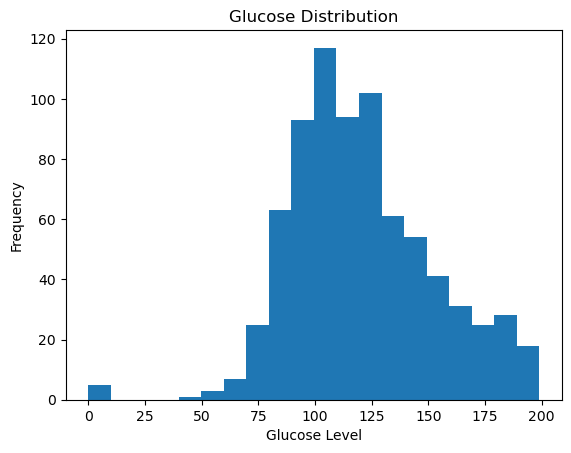

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Glucose'], bins=20)
plt.title("Glucose Distribution")
plt.xlabel("Glucose Level")
plt.ylabel("Frequency")
plt.show()

SCATTER PLOT

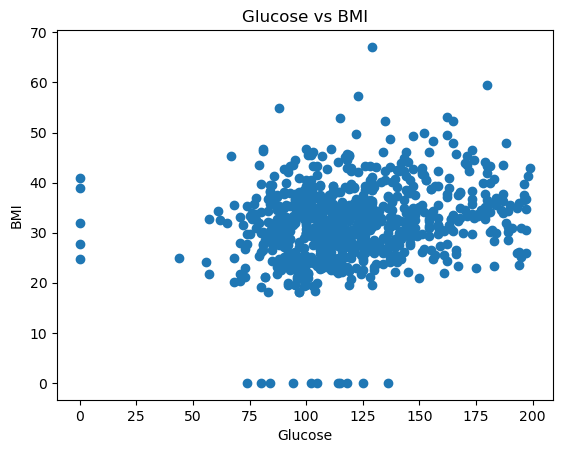

In [12]:
plt.figure()
plt.scatter(df['Glucose'], df['BMI'])
plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

LINE PLOT

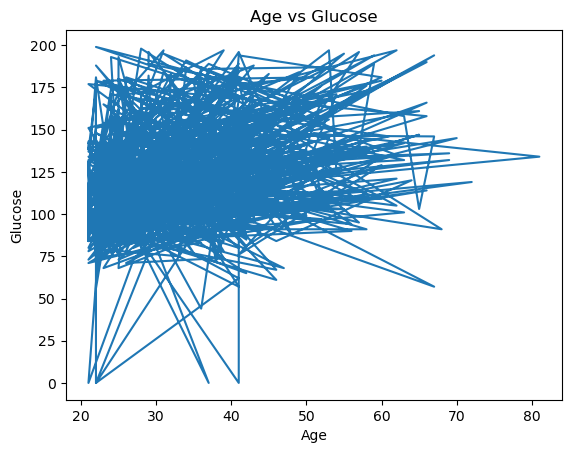

In [13]:
plt.figure()
plt.plot(df['Age'], df['Glucose'])
plt.title("Age vs Glucose")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.show()

BAR CHART

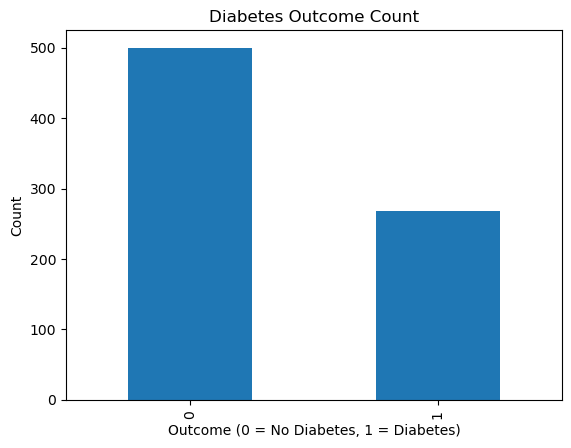

In [14]:
plt.figure()
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Outcome Count")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

BOX PLOT

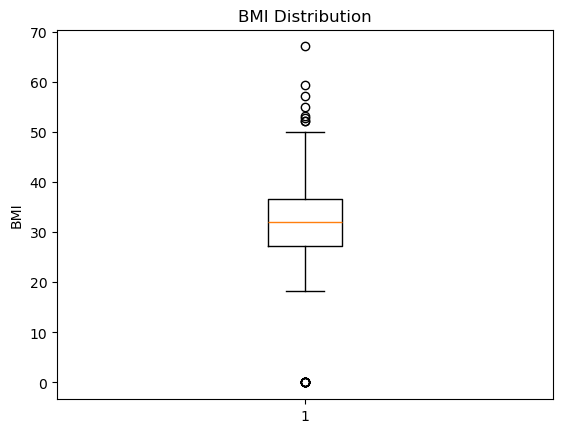

In [15]:
plt.figure()
plt.boxplot(df['BMI'])
plt.title("BMI Distribution")
plt.ylabel("BMI")
plt.show()

PIE CHART

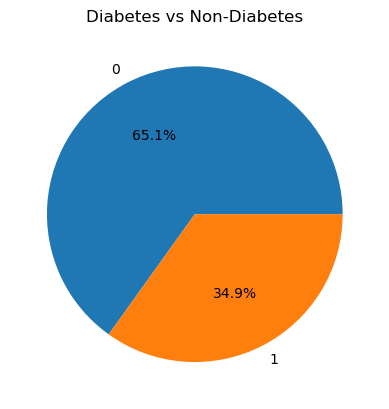

In [16]:
plt.figure()
df['Outcome'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Diabetes vs Non-Diabetes")
plt.ylabel("")
plt.show()